In [1]:
from mpasdiag import MPAS2DProcessor, MPASConfig, GeographicBounds, MPASWindPlotter, WindPlotStyle


In [2]:
proc = MPAS2DProcessor(grid_file="../data/grids/x1.10242.static.nc")
proc.load_2d_data("../data/u240k/diag")

In [3]:
tindex = 1
u = proc.get_2d_variable_data("u10", tindex)
v = proc.get_2d_variable_data("v10", tindex)
lon, lat = proc.extract_2d_coordinates_for_variable("u10", u)

In [4]:
cfg = MPASConfig()
cfg.lon_min, cfg.lon_max = -130, -50      # CONUS
cfg.lat_min, cfg.lat_max =   20,  60
cfg.remap_engine, cfg.remap_method = "kdtree", "nearest"
bounds = GeographicBounds(cfg.lon_min, cfg.lon_max, cfg.lat_min, cfg.lat_max)

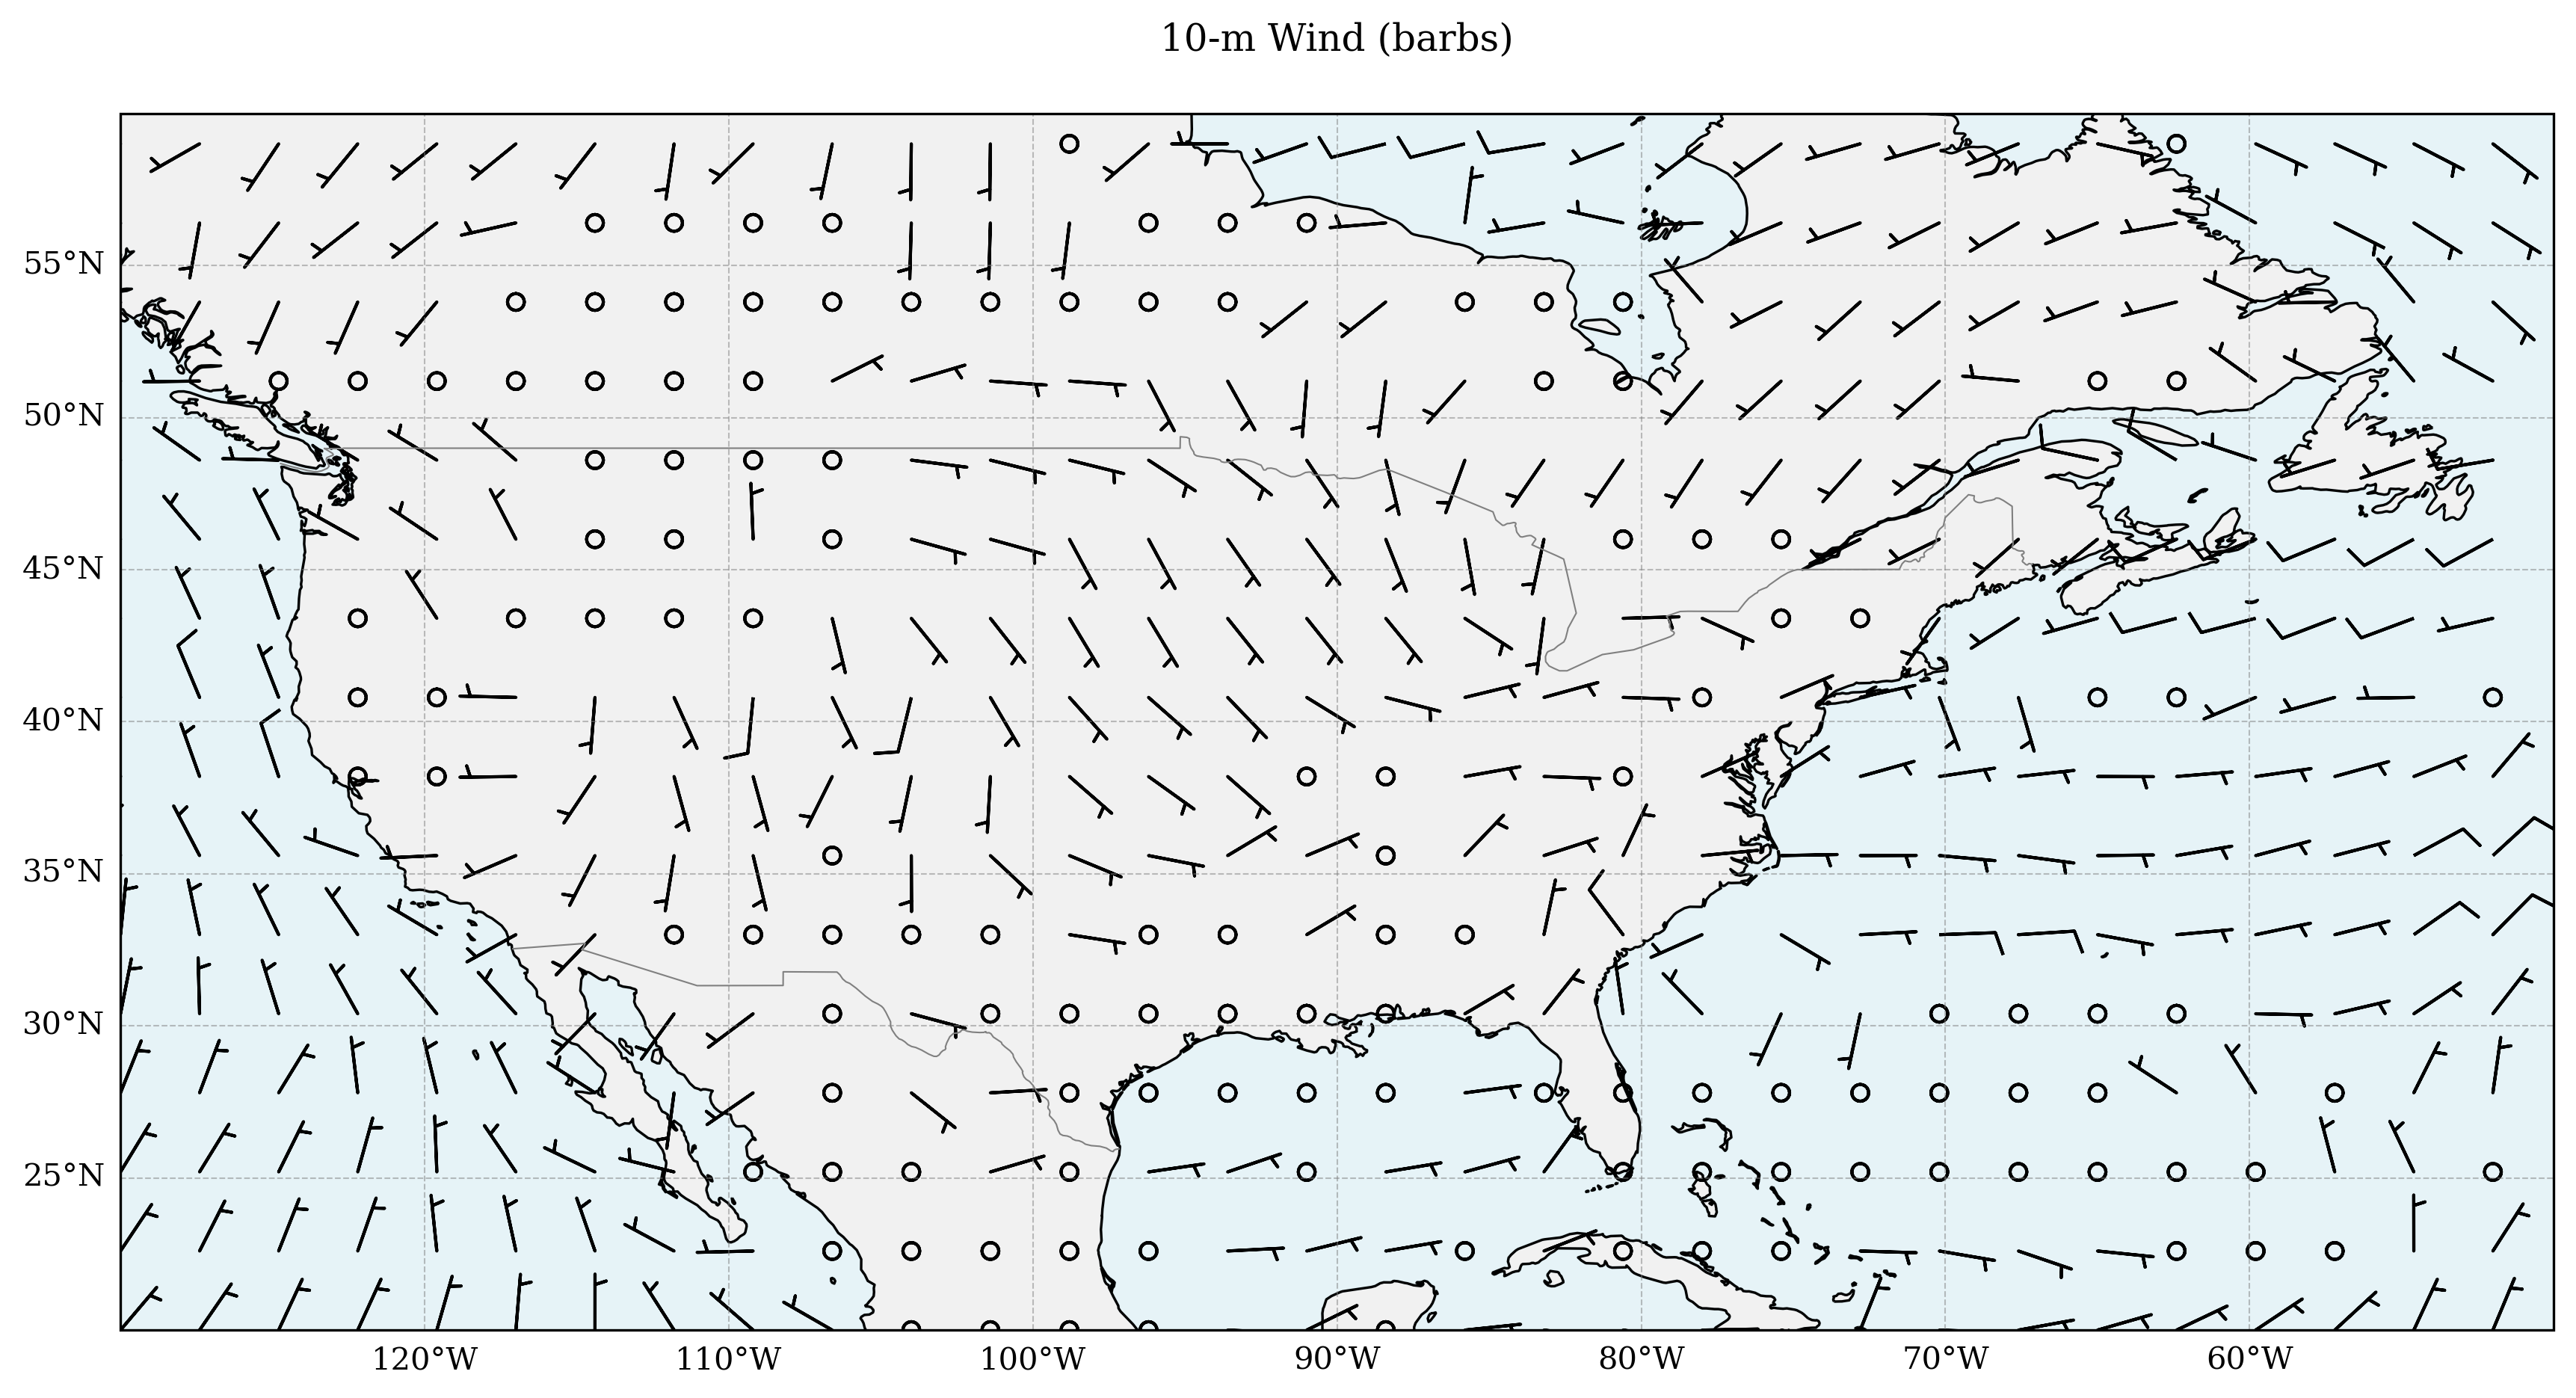

In [5]:
wind = MPASWindPlotter(figsize=(14, 11), dpi=300)
fig, ax = wind.create_wind_plot(
    lon=lon, lat=lat, u_data=u.values, v_data=v.values,
    bounds=bounds,
    style=WindPlotStyle(plot_type="barbs", subsample=-1, title="10-m Wind (barbs)"),
    grid_resolution=0.1, regrid_method="linear", config=cfg,
)

In [6]:
wind.save_plot("./output/wind_barbs_conus", formats=["png"])
wind.close_plot()